# [EDA] Exploring Turkish University Admissions (2019-2024)

**A starter notebook for exploring the Turkish University Admissions dataset.**

This notebook provides a basic exploratory data analysis (EDA) to uncover initial trends and insights. We will expand on the initial data overview, look at overall trends, top universities/cities, and dive into the most competitive departments and fields.

---

### **(TR) Türkiye Üniversite Yerleştirme Verileri ile Keşifsel Analiz**

**Bu başlangıç notebook'u, Türkiye Üniversite Yerleştirme veri setini keşfetmek için hazırlanmıştır.**

Bu çalışmada, veri setine daha detaylı bir ilk bakış atacak, genel eğilimleri inceleyecek, en rekabetçi bölümleri, alanların popülerlik değişimini ve Devlet-Vakıf üniversiteleri arasındaki farkları analiz edeceğiz.

## **1. Setup and Data Loading**
First, let's import the necessary libraries and load our main dataset.

---
### **(TR) 1. Kütüphanelerin Yüklenmesi ve Veri Setinin Okunması**
İlk olarak, gerekli kütüphaneleri import edip ana veri setimizi yükleyelim.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# Load the dataset
# On Kaggle, the path is usually '/kaggle/input/turkish-university-admissions/01_university_admissions_turkey_2019_2024.csv'
df = pd.read_csv('../data/all_in_one_denormalized.csv')

## **2. Detailed Data Inspection**
Let's get a comprehensive first look at our data's structure, summary statistics, missing values, and categorical features.

---
### **(TR) 2. Detaylı Veri İncelemesi**
Veri setimizin yapısına, özet istatistiklerine, eksik değerlerine ve kategorik özelliklerine kapsamlı bir ilk bakış atalım.

### 2.1. Basic Information / (TR) Temel Bilgiler

In [2]:
print(f"Dataset Shape (Rows, Columns): {df.shape}\n")
print("Data Types and Non-Null Counts:")
df.info()

Dataset Shape (Rows, Columns): (128352, 39)

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128352 entries, 0 to 128351
Data columns (total 39 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   program_code                     128352 non-null  int64  
 1   year                             128352 non-null  int64  
 2   university_name                  128352 non-null  object 
 3   city                             128352 non-null  object 
 4   university_type                  128352 non-null  object 
 5   department_name                  128352 non-null  object 
 6   faculty_name                     127475 non-null  object 
 7   score_type                       128352 non-null  object 
 8   scholarship_type                 128352 non-null  object 
 9   is_undergraduate                 128352 non-null  bool   
 10  all_tags                         70270 non-null   o

## **3. Yearly Trends: Quotas vs. Placements**
How have the total number of university quotas and enrolled students changed over the years?

---
### **(TR) 3. Yıllık Trendler: Kontenjan ve Yerleşen Sayıları**
Yıllar içinde toplam üniversite kontenjanları ve yerleşen öğrenci sayıları nasıl değişti?

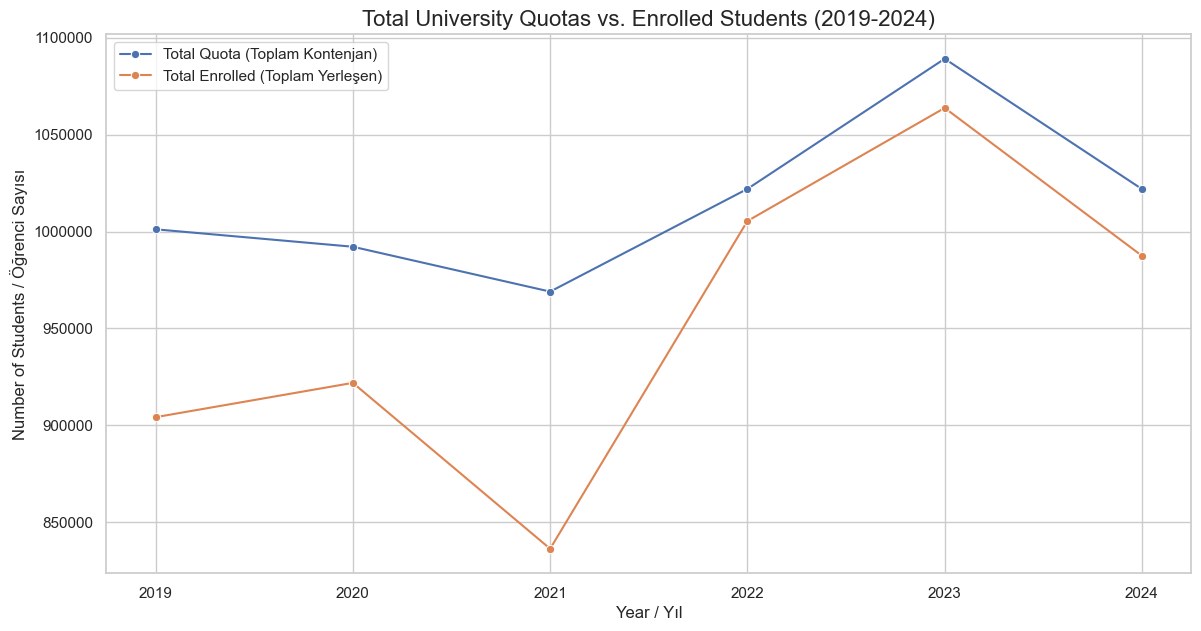

In [3]:
yearly_stats = df.groupby('year')[['total_quota', 'total_enrolled']].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_stats, x='year', y='total_quota', marker='o', label='Total Quota (Toplam Kontenjan)')
sns.lineplot(data=yearly_stats, x='year', y='total_enrolled', marker='o', label='Total Enrolled (Toplam Yerleşen)')

plt.title('Total University Quotas vs. Enrolled Students (2019-2024)', fontsize=16)
plt.xlabel('Year / Yıl')
plt.ylabel('Number of Students / Öğrenci Sayısı')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## **4. The Most Competitive Departments in Turkey (2024)**
Which specific university departments are the hardest to get into? Let's list the top 20 based on their final placement rank in 2024.

---
### **(TR) 4. Türkiye'nin En Rekabetçi Bölümleri (2024)**
Hangi üniversite bölümlerine girmek en zoru? 2024 yılı taban sıralamalarına göre en rekabetçi ilk 20 bölümü listeleyelim.

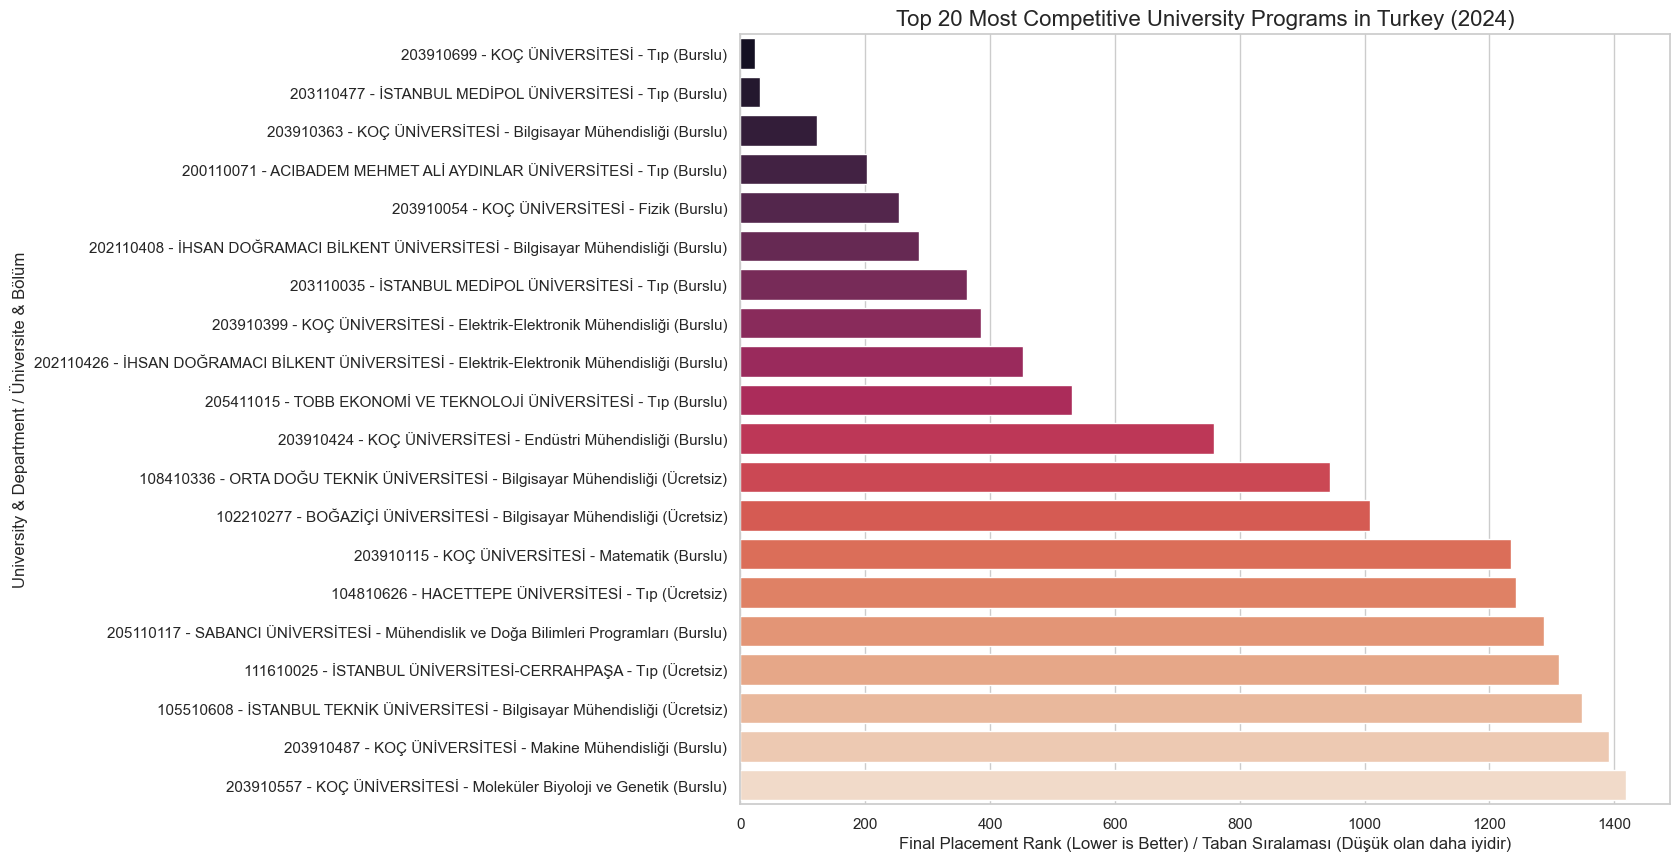

In [4]:
# Filter for undergraduate programs in 2024 with valid ranks
top_programs_2024 = df[
    (df['year'] == 2024) &
    (df['is_undergraduate'] == True) &
    (df['score_type'] == 'SAY') 
].dropna(subset=['final_rank_012']).sort_values('final_rank_012')

# Create a combined label for the plot
top_programs_2024['full_name'] = top_programs_2024["program_code"].astype(str) + " - " + top_programs_2024['university_name'] + ' - ' + top_programs_2024['department_name'] + ' (' + top_programs_2024['scholarship_type'] + ')'

# Plot the top 20
plt.figure(figsize=(12, 10))
sns.barplot(data=top_programs_2024.head(20), y='full_name', x='final_rank_012', palette='rocket', hue="full_name", legend=False)
plt.title('Top 20 Most Competitive University Programs in Turkey (2024)', fontsize=16)
plt.xlabel('Final Placement Rank (Lower is Better) / Taban Sıralaması (Düşük olan daha iyidir)')
plt.ylabel('University & Department / Üniversite & Bölüm')
plt.show()

**Observation:** As expected, the list is dominated by top universities such as Koç, Medipol, and Bilkent. This chart provides a clear snapshot of the “elite among the elite” programs.

---
**Gözlem:** Liste, beklendiği gibi, önde gelen Koç, Medipol, Bilkent gibi üniversiteler tarafından domine ediliyor. Bu grafik, "elitin eliti" programların net bir fotoğrafını çekiyor.

## **5. Popularity Trends of Major Academic Fields**
How has the popularity of major fields like Engineering, Medicine, and Law changed over time? We'll track the total number of enrolled students for each field.

---
### **(TR) 5. Ana Akademik Alanların Popülerlik Trendleri**
Mühendislik, Tıp ve Hukuk gibi ana alanların popülerliği zamanla nasıl değişti? Her bir alan için toplam yerleşen öğrenci sayısını takip edelim.

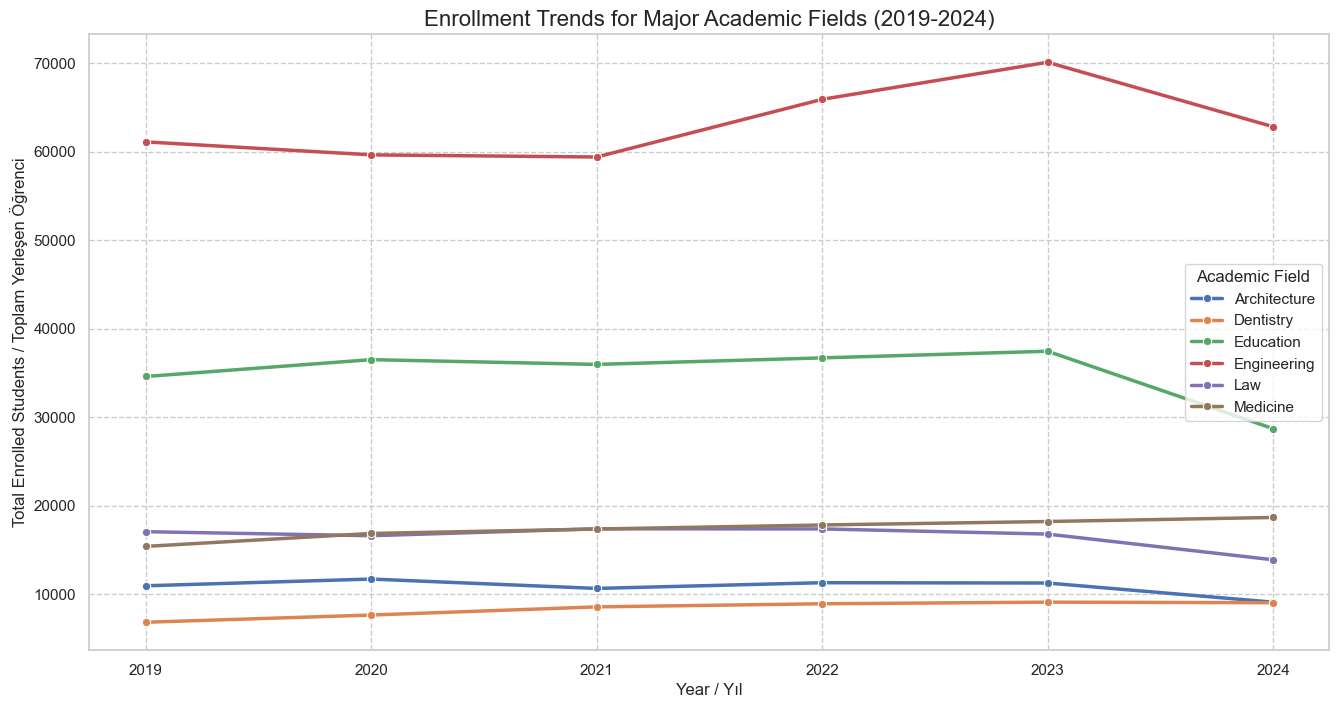

In [5]:
# A simple function to categorize departments into broader fields
def map_field(department_name):
    if 'Mühendisliği' in department_name:
        return 'Engineering'
    if 'Tıp' in department_name:
        return 'Medicine'
    if 'Hukuk' in department_name:
        return 'Law'
    if 'Diş Hekimliği' in department_name:
        return 'Dentistry'
    if 'Öğretmenliği' in department_name:
        return 'Education'
    if 'Mimarlık' in department_name:
        return 'Architecture'
    return 'Other'

df['field'] = df['department_name'].apply(map_field)

# Group by year and field to sum enrolled students
field_trends = df[df['field'] != 'Other'].groupby(['year', 'field'])['total_enrolled'].sum().reset_index()

# Plot the trends
plt.figure(figsize=(16, 8))
sns.lineplot(data=field_trends, x='year', y='total_enrolled', hue='field', marker='o', linewidth=2.5)
plt.title('Enrollment Trends for Major Academic Fields (2019-2024)', fontsize=16)
plt.xlabel('Year / Yıl')
plt.ylabel('Total Enrolled Students / Toplam Yerleşen Öğrenci')
plt.legend(title='Academic Field')
plt.grid(True, which="both", ls="--")
plt.show()

**Observation:** This chart shows that the quotas for Medicine, Law, Architecture, and Dentistry have remained relatively stable over the years, while the fields of Engineering and Education have followed a more fluctuating trend.


---
**Gözlem:** Bu grafik, Tıp, Hukuk, Mimarlık ve Diş Hekimliği kontenjanlarının yıllar içinde daha istikrarlı bir şekilde devam ettiğini Mühendislik ve Eğitim alanlarının yıllar içinde daha değişken bir çizgi izlediğini gösteriyor. 

## **6. State vs. Foundation University: A Look at Top Programs**
How do State (Devlet) and Foundation (Vakıf) universities compare in terms of elite programs? Let's count how many programs each university type has in the top 10,000 ranks for 2024.

---
### **(TR) 6. Devlet ve Vakıf Üniversitesi: En İyi Programlara Bakış**
Elit programlar açısından Devlet ve Vakıf üniversiteleri nasıl bir karşılaştırmaya sahip? 2024 yılında her bir üniversite türünün ilk 10.000 sıralama diliminde kaç programı olduğunu sayalım.

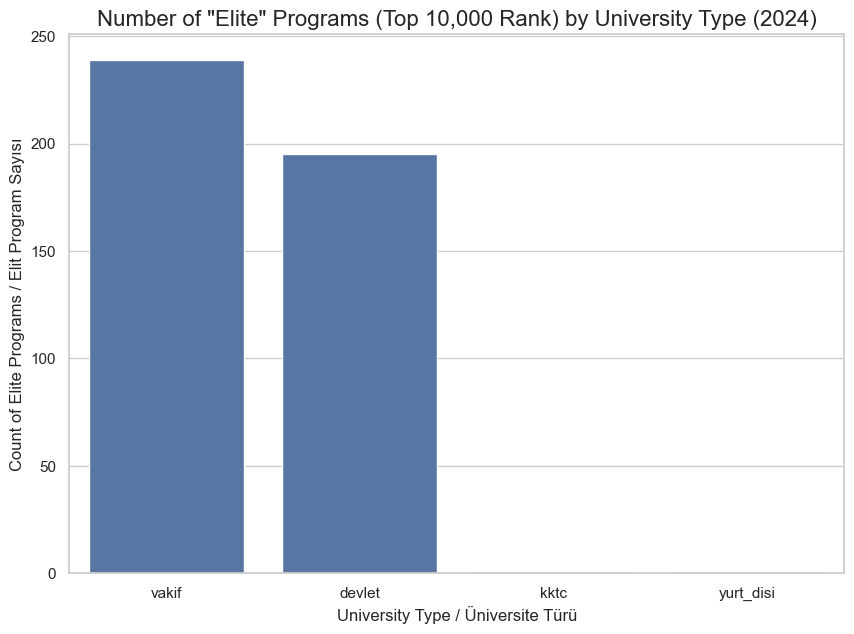

university_type
vakif        239
devlet       195
kktc           1
yurt_disi      1
Name: count, dtype: int64


In [6]:
# Filter for elite programs (rank <= 10000) in 2024
elite_programs = df[(df['year'] == 2024) & (df['final_rank_012'] <= 10000)]

# Count by university type
type_counts = elite_programs['university_type'].value_counts()

# Plot the comparison
plt.figure(figsize=(10, 7))
sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title('Number of "Elite" Programs (Top 10,000 Rank) by University Type (2024)', fontsize=16)
plt.xlabel('University Type / Üniversite Türü')
plt.ylabel('Count of Elite Programs / Elit Program Sayısı')
plt.show()

print(type_counts)

**Observation:** In 2024, foundation (private) universities have far more programs within the top 10,000 ranking bracket compared to public (state) universities. KKTC and international universities, on the other hand, are barely part of the competition, each represented by only one program.

---
**Gözlem:** 2024 yılında, Vakıf üniversiteleri ilk 10.000 diliminde Devlet üniversitelerinden çok daha fazla programa sahiptir. Bu KKTC ve Yurtdışı üniversiteleri ise 1'er bölümle rekabete çok dahil olamıyor.

## **7. Gender Distribution: Which Fields Have the Highest Female Student Ratio?**
Let’s analyze the gender distribution across different programs. Which programs attract more female students? Are there any programs that admit no male students at all? We will calculate the proportion of female students in each program for all years (2019–2024).

### **(TR) 7. Cinsiyet Dağılımı: Kadın Öğrenci Oranı En Yüksek Alanlar Hangileri?**
Farklı bölümlerdeki cinsiyet dağılımını analiz edelim. Hangi bölümler daha fazla kadın öğrenci çekiyor? Hiç erkek girmeyen bölümler var mı? Bütün yıllar(2019-2024) için bölümlerdeki kadın öğrenci oranını hesaplayacağız.

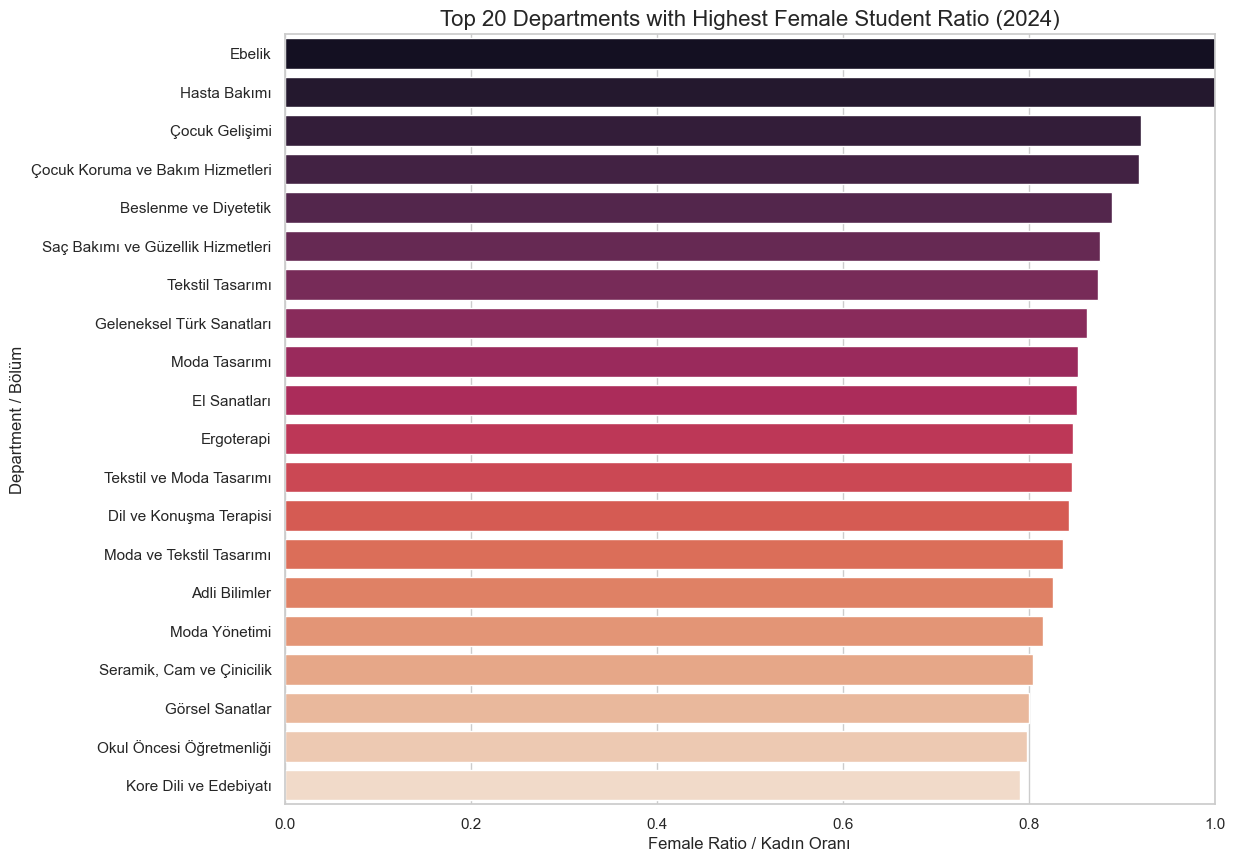

In [7]:
department_name_grouped = df.groupby('department_name').agg({
    'total_enrolled': 'sum',
    'male': 'sum',
    'female': 'sum'
}).reset_index()

# Filter departments with more than 30 enrolled students
department_name_grouped = department_name_grouped[department_name_grouped['total_enrolled'] > 30]

# Calculate
department_name_grouped["female_ratio"] = department_name_grouped["female"] / (department_name_grouped["male"] + department_name_grouped["female"])

# Sort
department_name_grouped = department_name_grouped.sort_values(by=['female_ratio', 'female'], ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=department_name_grouped.head(20), y='department_name', x='female_ratio', palette='rocket', hue="department_name", legend=False)
plt.title('Top 20 Departments with Highest Female Student Ratio (2024)', fontsize=16)
plt.xlabel('Female Ratio / Kadın Oranı')
plt.ylabel('Department / Bölüm')
plt.xlim(0, 1)
plt.show()

**Observation**: Across all years (2019–2024), we see that the female student ratio reaches 100% in midwifery and nursing programs. Presumably, these programs do not admit male students. In other programs, the ratio gradually declines from the 90% range downward.

---

**Gözlem:** Tüm yıllarda (2019-2024) kadın öğrenci oranının %100 oranla en çok ebelik ve hasta bakımı bölümlerinde olduğunu görüyoruz. Bu bölümlere sanırım erkek öğrenci alımı yapılmıyor. Diğer bölümlerde ise bu oran %90'lardan aşağıya doğru devam ediyor.

## **8. University Prestige Beyond Ranks: Where Do High-Achievers Go?**
Placement rank isn't the only measure of prestige. Let's see which universities attract students with the highest average high school GPAs (avg_obp_012). This shows where students who were academically successful throughout high school tend to enroll.

---

### **(TR) 8. Sıralamanın Ötesinde Prestij: Lise Başarısı En Yüksek Öğrenciler Nereye Gidiyor?**
Yerleştirme sıralaması tek prestij ölçütü değildir. Hangi üniversitelerin en yüksek Ortalama Ortaöğretim Başarı Puanı'na (avg_obp_012) sahip öğrencileri çektiğine bakalım. Bu, lise hayatı boyunca akademik olarak başarılı olmuş öğrencilerin nereyi tercih ettiğini gösterir.

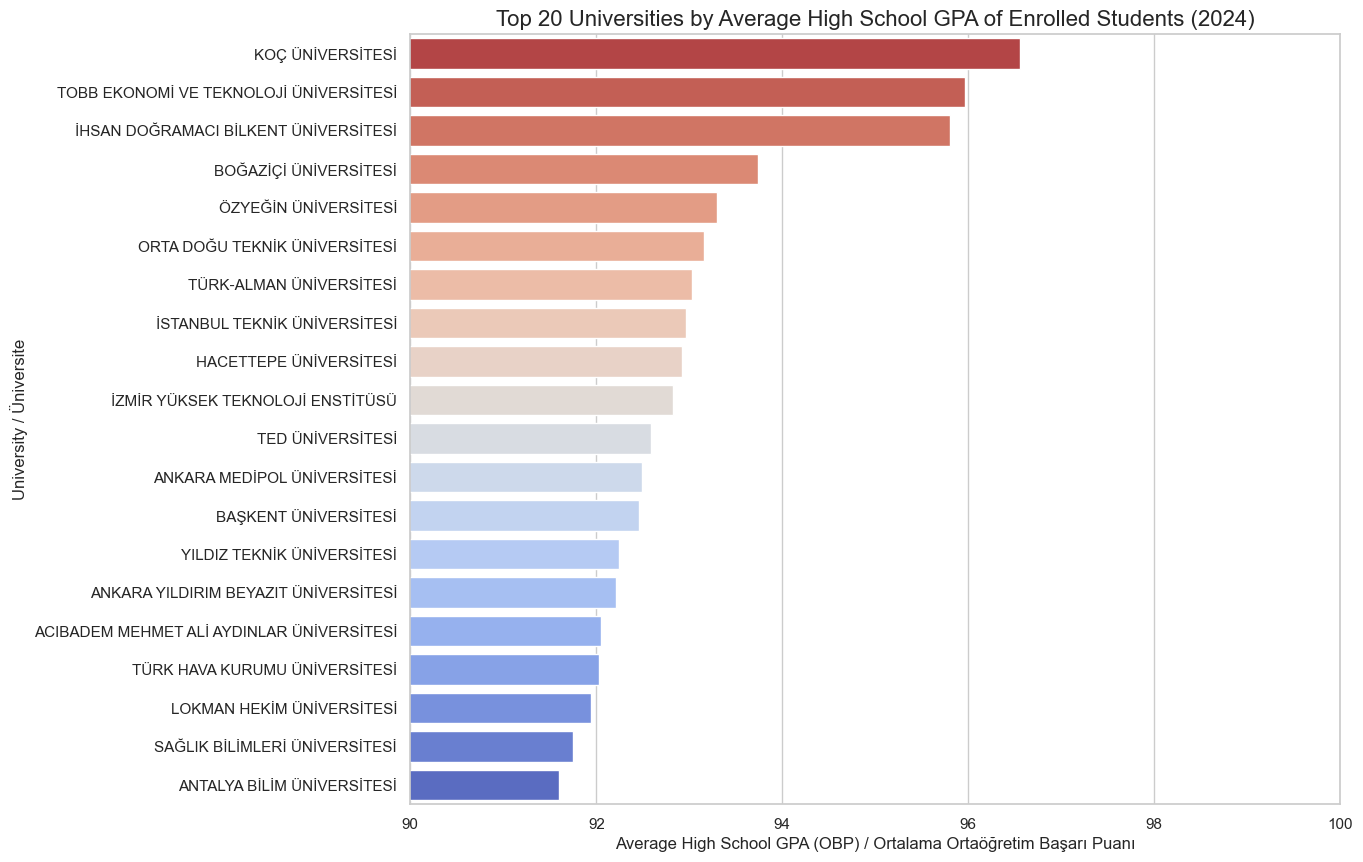

In [8]:
# Filter for 2024 undergraduate programs with valid OBP data
obp_df = df[
    (df['year'] == 2024) &
    (df['is_undergraduate'] == True) &
    (df['score_type'] == 'SAY')
].dropna(subset=['avg_obp_012'])

# We will only consider universities with at least 10 programs with OBP data for a fair comparison
uni_program_counts = obp_df['university_name'].value_counts()
valid_universities = uni_program_counts[uni_program_counts >= 10].index
obp_df_filtered = obp_df[obp_df['university_name'].isin(valid_universities)]

# Calculate the average OBP for each university
top_obp_unis = obp_df_filtered.groupby('university_name')['avg_obp_012'].mean().sort_values(ascending=False).head(20)


# Plot the top 20 universities
plt.figure(figsize=(12, 10))
sns.barplot(y=top_obp_unis.index, x=top_obp_unis.values / 5, palette='coolwarm_r', hue=top_obp_unis.index, legend=False)
plt.title('Top 20 Universities by Average High School GPA of Enrolled Students (2024)', fontsize=16)
plt.xlabel('Average High School GPA (OBP) / Ortalama Ortaöğretim Başarı Puanı')
plt.ylabel('University / Üniversite')
plt.xlim(90, 100) # Set x-axis limits to better see the differences
plt.show()

## **9. Tracking the Future: The Rise of AI and Data Science Programs**
This dataset can reveal emerging trends. Let's track the growth of programs related to Artificial Intelligence and Data Science by looking at their total offered quotas over the years.

### **(TR) 9. Geleceği Takip Etmek: Yapay Zeka ve Veri Bilimi Programlarının Yükselişi**
Bu veri seti, yeni ortaya çıkan trendleri ortaya çıkarabilir. Yapay Zeka ve Veri Bilimi ile ilgili programların büyümesini, yıllara göre açılan toplam kontenjanlarını inceleyerek takip edelim.

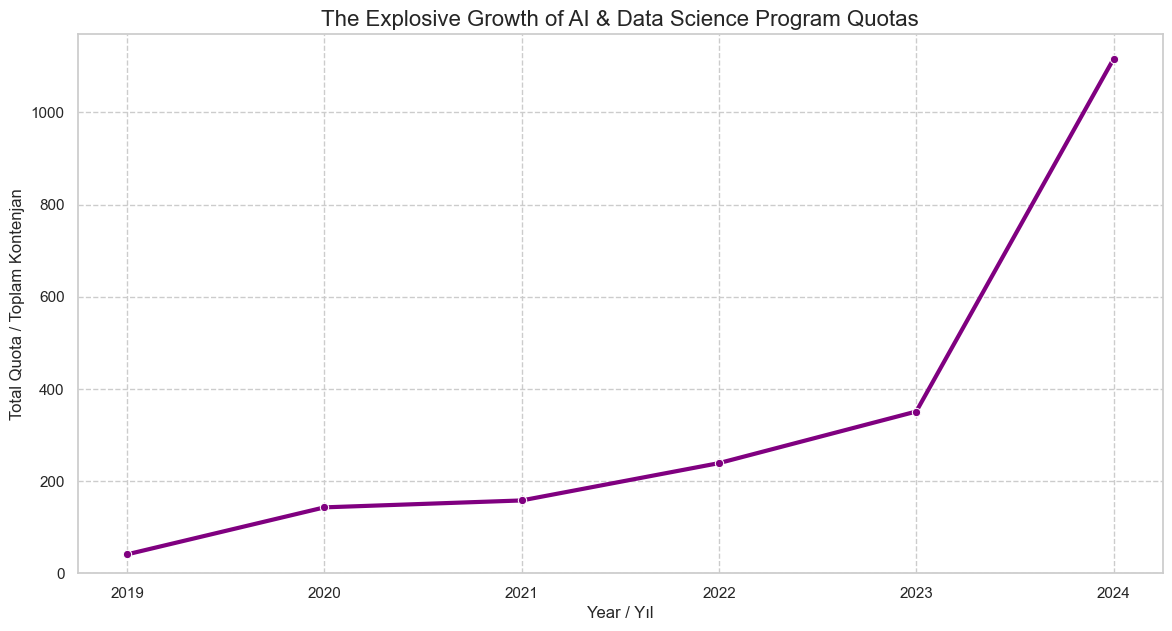

In [9]:
# Define keywords for AI and Data Science related programs
ai_keywords = ['Yapay Zeka', 'Veri Bilimi', 'Data']

# Filter departments containing any of the keywords (case-insensitive)
ai_df = df[df['department_name'].str.contains('|'.join(ai_keywords), case=False, na=False)]

# Group by year and sum the total quota
ai_quota_trends = ai_df.groupby('year')['total_quota'].sum().reset_index()

# Plot the trend
plt.figure(figsize=(14, 7))
sns.lineplot(data=ai_quota_trends, x='year', y='total_quota', marker='o', linewidth=3, color='purple')
plt.title('The Explosive Growth of AI & Data Science Program Quotas', fontsize=16)
plt.xlabel('Year / Yıl')
plt.ylabel('Total Quota / Toplam Kontenjan')
plt.grid(True, which="both", ls="--")
plt.ylim(0) # Start y-axis at 0
plt.show()

**Observation**: The total quota for programs related to Artificial Intelligence and Data Science has shown an explosive growth, especially in the past few years.

---

**Gözlem**: Yapay Zeka ve Veri Bilimi ile ilgili programların toplam kontenjanı, özellikle son birkaç yılda patlayıcı bir büyüme göstermiştir.

#### **10. Next Steps**

- The Gender Equality Scorecard: Ranking the Most and Least Gender-Balanced Programs.

- "The Dream School" Analysis: Which Universities Capture the Most "First Choice" Placements?

- The Volatility Report: Identifying Departments with the Most Unpredictable Rankings.

**Feel free to fork this notebook and continue exploring!**

#### **10. (TR) Sonraki Adımlar**

- Cinsiyet Eşitliği Karnesi: En Dengeli ve En Dengesiz Bölümlerin Sıralaması.

- "Hayalimdeki Okul" Analizi: Hangi Üniversiteler En Çok "İlk Tercih"ten Öğrenci Alıyor?

- Volatilite Raporu: Sıralaması En Çok Dalgalanan (İstikrarsız) Bölümleri Belirlemek.

**Bu notebook'u kopyalayıp veri setini keşfetmeye devam etmekten çekinmeyin!**